# Data Science & AI Machine Learning
## 🏦 Prediksi Kelayakan Kredit Bank (Multi-Variabel Kompleks)
Live Demo Data Series 19.0 - by Naufal Zaki Aulia

### 1. Ambil Data Open Source (Loan Prediction Dataset)
Di dunia nyata, Bank tidak hanya melihat Gaji untuk menyetujui pinjaman. Mereka melihat **banyak sekali faktor**: Status Pernikahan, Jumlah Tanggungan Anak, Tingkat Pendidikan, Jenis Pekerjaan, Lokasi Rumah, dll.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Langsung download dataset dari Github
url = 'https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv'
df = pd.read_csv(url)

print("Total Nasabah:", len(df))
print("Jumlah Pertimbangan (Kolom):", len(df.columns))
display(df.head())

Total Nasabah: 614
Jumlah Pertimbangan (Kolom): 13


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### 2. Data Engineering (Transformasi Data Besar)
Mesin AI tidak mengerti teks (seperti "Urban" atau "Female"). Pekerjaan Data Scientist di sini adalah mengubah semua kerumitan profil manusia ini menjadi angka yang bisa dipahami algoritma, serta menciptakan metrik bisnis (*Rasio Hutang*).

In [2]:
# 1. Mengubah Teks jadi Angka (Categorical Encoding)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].map({'0': 0, '1': 1, '2': 2, '3+': 3})
df['Education_Num'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})
df['Property_Area'] = df['Property_Area'].map({'Urban': 2, 'Semiurban': 1, 'Rural': 0})
df['Loan_Status_Num'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# 2. Isi data yang kosong (Imputasi)
df = df.fillna(df.mode().iloc[0]) # Cara cepat mengisi semua kolom kosong dengan nilai mayoritas

# 3. FEATURE ENGINEERING (Senjata Rahasia Bisnis)
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Cicilan_Per_Bulan'] = (df['LoanAmount'] * 1000) / df['Loan_Amount_Term']
df['Rasio_Hutang'] = df['Cicilan_Per_Bulan'] / df['TotalIncome']

print("Semua variabel sudah dikonversi menjadi angka dan siap dicerna AI!")
display(df[['Gender', 'Married', 'Dependents', 'Property_Area', 'TotalIncome', 'Rasio_Hutang']].head())

Semua variabel sudah dikonversi menjadi angka dan siap dicerna AI!


,Gender,Married,Dependents,Property_Area,TotalIncome,Rasio_Hutang
0,1.0,0.0,0.0,2,5849.0,0.056990
1,1.0,1.0,1.0,0,6091.0,0.058374
2,1.0,1.0,0.0,2,3000.0,0.061111
3,1.0,1.0,0.0,2,4941.0,0.067463
4,1.0,0.0,0.0,2,6000.0,0.065278


### 3. Data Analysis (Melihat Pola Manusia)
Secara manual, manusia bisa menganalisis hubungan 1-2 variabel dengan mudah. (Contoh: Rata-rata orang berpendidikan sarjana peluang ACC-nya lebih besar).

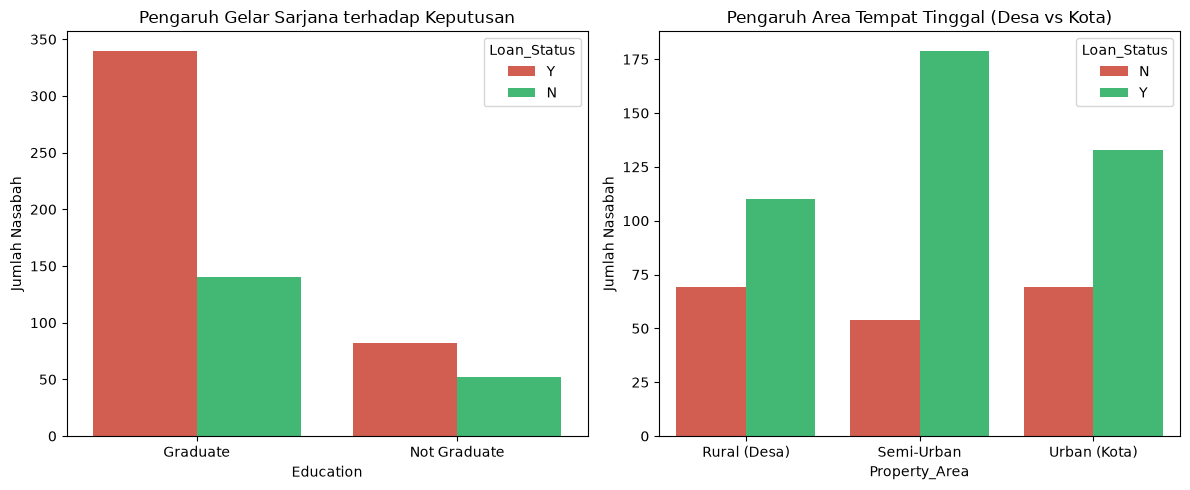

In [3]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Education', hue='Loan_Status', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Pengaruh Gelar Sarjana terhadap Keputusan')
plt.ylabel('Jumlah Nasabah')

plt.subplot(1, 2, 2)
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, palette=['#e74c3c', '#2ecc71'])
plt.title('Pengaruh Area Tempat Tinggal (Desa vs Kota)')
plt.xticks(ticks=[0, 1, 2], labels=['Rural (Desa)', 'Semi-Urban', 'Urban (Kota)'])
plt.ylabel('Jumlah Nasabah')

plt.tight_layout()
plt.show()

# Insight Manual:
# - Sarjana (Graduate) memang lebih banyak disetujui.
# - Menariknya, orang di kawasan Semi-Urban punya rasio persetujuan paling aman.

### 4. Machine Learning (Alasan Mutlak Kenapa Kita Butuh AI)
Jika Bapak/Ibu disuruh menebak: *"Seorang pria, belum menikah, lulus SMA, *freelancer*, tinggal di desa, gaji $2000, tapi riwayat kreditnya bagus. Apakah disetujui?"*

Otak manusia tidak sanggup membuat **RUMUS PASTI** untuk mengkombinasikan **10 variabel** secara bersamaan untuk jutaan nasabah. Jika pakai *If-Else* manual, akan ada bias asumsi manusia. Di sinilah **Machine Learning (XGBoost)** mengambil alih untuk membedah dimensi yang kompleks secara matematis.

In [4]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# AI DIBERI TUGAS MENELAN 10 VARIABEL SEKALIGUS!
X = df[['Gender', 'Married', 'Dependents', 'Education_Num', 'Self_Employed', 
        'Property_Area', 'Credit_History', 'TotalIncome', 'LoanAmount', 'Rasio_Hutang']]
y = df['Loan_Status_Num']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Latih AI (Membiarkan algoritma mencari pola tersembunyi dari interaksi 10 variabel tersebut)
model = XGBClassifier(eval_metric='logloss', max_depth=4, learning_rate=0.05, n_estimators=150, random_state=42)
model.fit(X_train, y_train)

# Evaluasi Kecerdasan AI
prediksi = model.predict(X_test)
akurasi = accuracy_score(y_test, prediksi)
print(f"🚀 Akurasi AI Bank (Menganalisis 10 Variabel Kompleks): {akurasi * 100:.1f}%")

🚀 Akurasi AI Bank (Menganalisis 10 Variabel Kompleks): 80.5%


### 5. Simulator Sistem Inti Perbankan (The WOW Factor)
Ini adalah wujud asli aplikasi form pengajuan kredit di perbankan. Silakan isi **semua pertimbangan** ini, dan biarkan AI yang memutar otak menganalisis profil risiko Anda secara utuh.

In [5]:
def sistem_kredit_lengkap(gender, married, tanggungan, edukasi, freelancer, area, 
                          gaji_utama, gaji_pasangan, pinjaman_k, tenor_bulan, riwayat):
    
    # Konversi jawaban dari Dropdown manusia ke Angka untuk AI
    gen_num = 1 if gender == 'Pria' else 0
    mar_num = 1 if married == 'Sudah Menikah' else 0
    dep_num = int(tanggungan) if tanggungan != '3+' else 3
    edu_num = 1 if edukasi == 'Sarjana (S1/S2/S3)' else 0
    emp_num = 1 if freelancer == 'Ya (Freelance/Usaha)' else 0
    
    if area == 'Kota (Urban)': area_num = 2
    elif area == 'Pinggir Kota (Semi-Urban)': area_num = 1
    else: area_num = 0
        
    riwayat_num = 1.0 if riwayat == 'Baik (Lancar)' else 0.0
    
    # Hitungan Financial Engineering
    total_income = gaji_utama + gaji_pasangan
    pinjaman_asli = pinjaman_k / 1000  
    cicilan = pinjaman_k / tenor_bulan
    rasio_hutang = cicilan / total_income
    
    # Susun Data 10 Variabel Sesuai Format Training
    input_data = pd.DataFrame([[gen_num, mar_num, dep_num, edu_num, emp_num, area_num, 
                                riwayat_num, total_income, pinjaman_asli, rasio_hutang]], 
                              columns=['Gender', 'Married', 'Dependents', 'Education_Num', 'Self_Employed', 
                                       'Property_Area', 'Credit_History', 'TotalIncome', 'LoanAmount', 'Rasio_Hutang'])
    
    # Prediksi Keputusan
    prob_acc = model.predict_proba(input_data)[0][1] * 100
    
    if prob_acc > 70:
        pesan = "✅ APPROVE! Nasabah Sangat Layak."
        warna = "#2ecc71"
    elif prob_acc > 40:
        pesan = "⚠️ PENDING. Perlu Pengecekan Lapangan Tambahan."
        warna = "#f39c12"
    else:
        pesan = "❌ REJECT! Risiko Gagal Bayar Terlalu Tinggi."
        warna = "#e74c3c"
        
    display(HTML(f"""
        <div style='background-color:#2c3e50; padding:20px; border-radius:10px; border: 3px solid {warna}; text-align:center;'>
            <h1 style='color:{warna}; margin:0;'>{pesan}</h1>
            <div style='color:white; margin-top:15px; font-size:16px;'>
                <p>AI telah mengkalkulasi <b>10 variabel</b> profil Anda secara bersamaan.</p>
                <p>Rasio Beban Hutang Terdeteksi: <b>{(rasio_hutang*100):.1f}%</b></p>
                <p><b>Skor Peluang Kelayakan: {prob_acc:.1f}%</b></p>
            </div>
        </div>
    """))

print("=== PORTAL EVALUASI KREDIT (FULL SYSTEM) ===")
_ = widgets.interact(
    sistem_kredit_lengkap,
    gender=widgets.Dropdown(options=['Pria', 'Wanita'], value='Pria', description='Gender:'),
    married=widgets.Dropdown(options=['Sudah Menikah', 'Belum Menikah'], value='Sudah Menikah', description='Status Nikah:'),
    tanggungan=widgets.Dropdown(options=['0', '1', '2', '3+'], value='0', description='Jml Anak:'),
    edukasi=widgets.Dropdown(options=['Sarjana (S1/S2/S3)', 'Lulusan SMA/Bawahnya'], value='Sarjana (S1/S2/S3)', description='Pendidikan:'),
    freelancer=widgets.Dropdown(options=['Ya (Freelance/Usaha)', 'Tidak (Karyawan Tetap)'], value='Tidak (Karyawan Tetap)', description='Freelancer?:'),
    area=widgets.Dropdown(options=['Kota (Urban)', 'Pinggir Kota (Semi-Urban)', 'Desa (Rural)'], value='Kota (Urban)', description='Area Rumah:'),
    gaji_utama=widgets.IntSlider(min=1000, max=15000, value=5000, step=500, description='Gaji Anda ($):'),
    gaji_pasangan=widgets.IntSlider(min=0, max=15000, value=0, step=500, description='Gaji Pasangan:'),
    pinjaman_k=widgets.IntSlider(min=10000, max=500000, value=150000, step=10000, description='Pinjaman ($):'),
    tenor_bulan=widgets.Dropdown(options=[12, 24, 60, 120, 360], value=360, description='Tenor (Bulan):'),
    riwayat=widgets.Dropdown(options=['Baik (Lancar)', 'Buruk (Pernah Macet)'], value='Baik (Lancar)', description='Riwayat Kredit:')
)

=== PORTAL EVALUASI KREDIT (FULL SYSTEM) ===


interactive(children=(Dropdown(description='Gender:', options=('Pria', 'Wanita'), value='Pria'), Dropdown(desc…